# Customer-Level Analysis (EDA + Business Findings)

**Grain:** one row per `customer_unique_id`. **Input:** `cleaned_customer_level_master_table.csv`
(from `data-processing-customer_master_cleaning.ipynb`; falls back to the raw master automatically).

This single notebook consolidates what were two notebooks — the broad **exploratory EDA** and the
**detailed business analysis** — into one story. Within each theme it first *explores* the pattern,
then *focuses* on the decision it implies. All relationships are **associational, not causal**.

**Contents**
1. Data quality & coverage
2. Customer base & value concentration
3. Repeat purchasing & customer value
4. Delivery & satisfaction
5. Geographic experience & risk
6. Priority customer segments
7. Payment behaviour
8. Basket diversity
9. Acquisition cohort & loyalty
10. Relationship overview (correlations)
11. Takeaways, actions & open questions

## 0. Setup and data load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:,.2f}'.format)

# Shared palette for the "focused" charts (exploratory charts keep their original colours)
PALETTE = dict(navy='#1b2a4a', red='#d1495b', green='#2a9d8f',
               amber='#e9c46a', orange='#e76f51', grey='#8d99ae')

# --- Locate the cleaned table (preferred) or fall back to the raw master ---
here = Path.cwd()
roots = [here, here.parent, here / 'data-visualization', here.parent / 'data-visualization',
         here / 'data_cleaning', here.parent / 'data_cleaning']
def _find(name):
    return next((r / name for r in roots if (r / name).exists()), None)

cleaned = _find('cleaned_customer_level_master_table.csv')
if cleaned is not None:
    customers = pd.read_csv(cleaned, parse_dates=['first_order_date', 'last_order_date'])
    print('Loaded CLEANED customer table:', cleaned)
else:
    raw = _find('customer_level_master_table.csv')
    customers = pd.read_csv(raw, parse_dates=['first_order_date', 'last_order_date'])
    customers['has_review'] = customers['review_count'].gt(0)
    customers['has_delivery'] = customers['avg_actual_delivery_days'].notna()
    print('Cleaned table not found - loaded raw master with flags:', raw)

# --- Figures render INLINE by default (matches the rest of the repo, no outputs/ folder). ---
# Flip SAVE_FIGURES to True to ALSO export PNGs (e.g. when building the slide deck / report).
SAVE_FIGURES = False
repo_root = here.parent if here.name == 'data-visualization' else here
fig_dir = repo_root / 'outputs' / 'figures'
def save_fig(name):
    if SAVE_FIGURES:
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / name, dpi=130)

total_revenue = customers['total_payment_value'].sum()
print(f'Customers: {len(customers):,} rows x {customers.shape[1]} columns '
      f'| revenue R$ {total_revenue:,.0f}')
customers.head()

Loaded CLEANED customer table: E:\DVDProject\ecommerce-visual-analytics\data-visualization\cleaned_customer_level_master_table.csv
Customers: 96,096 rows x 26 columns | revenue R$ 16,008,872


,customer_unique_id,customer_orders,first_order_date,last_order_date,customer_city,customer_state,total_item_value,total_freight_value,total_payment_value,avg_payment_value,...,product_diversity,seller_diversity,repeat_customer_flag,late_delivery_rate,review_risk_flag,customer_tenure_days,has_review,has_delivery,zero_payment_flag,total_payment_value_capped
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,2018-05-10 10:56:27,cajamar,SP,129.90,12.00,141.90,141.90,...,1.00,1.00,False,0.00,False,0,True,True,False,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,2018-05-07 11:11:27,osasco,SP,18.90,8.29,27.19,27.19,...,1.00,1.00,False,0.00,False,0,True,True,False,27.19
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,2017-03-10 21:05:03,sao jose,SC,69.00,17.22,86.22,86.22,...,1.00,1.00,False,0.00,False,0,True,True,False,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,2017-10-12 20:29:41,belem,PA,25.99,17.63,43.62,43.62,...,1.00,1.00,False,0.00,False,0,True,True,False,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,2017-11-14 19:45:42,sorocaba,SP,180.00,16.89,196.89,196.89,...,1.00,1.00,False,0.00,False,0,True,True,False,196.89


## 1. Data quality & coverage

We make missing reviews and missing delivery data visible *before* interpreting any experience
metric. The cleaned table carries explicit `has_review` / `has_delivery` flags; nulls are never imputed.

In [2]:
audit = pd.DataFrame({
    'data_type': customers.dtypes.astype(str),
    'missing_values': customers.isna().sum(),
    'missing_rate': customers.isna().mean(),
    'distinct_values': customers.nunique(),
})

print(f'Customer rows: {len(customers):,}')
print(f'Duplicate customer IDs: {customers.customer_unique_id.duplicated().sum():,}')
print(f'Customers with a review: {customers.review_count.gt(0).mean():.1%}')
print(f'Customers with delivery-duration data: {customers.avg_actual_delivery_days.notna().mean():.1%}')
audit.sort_values('missing_rate', ascending=False)

Customer rows: 96,096
Duplicate customer IDs: 0
Customers with a review: 99.3%
Customers with delivery-duration data: 97.1%


,data_type,missing_values,missing_rate,distinct_values
avg_delivery_delay_days,float64,2740,0.03,331
avg_actual_delivery_days,float64,2740,0.03,248
avg_review_score,float64,716,0.01,26
avg_installments,float64,1,0.00,79
avg_payment_value,float64,1,0.00,28659
last_order_date,datetime64[us],0,0.00,95834
customer_orders,int64,0,0.00,9
first_order_date,datetime64[us],0,0.00,95837
customer_city,str,0,0.00,4119
customer_unique_id,str,0,0.00,96096


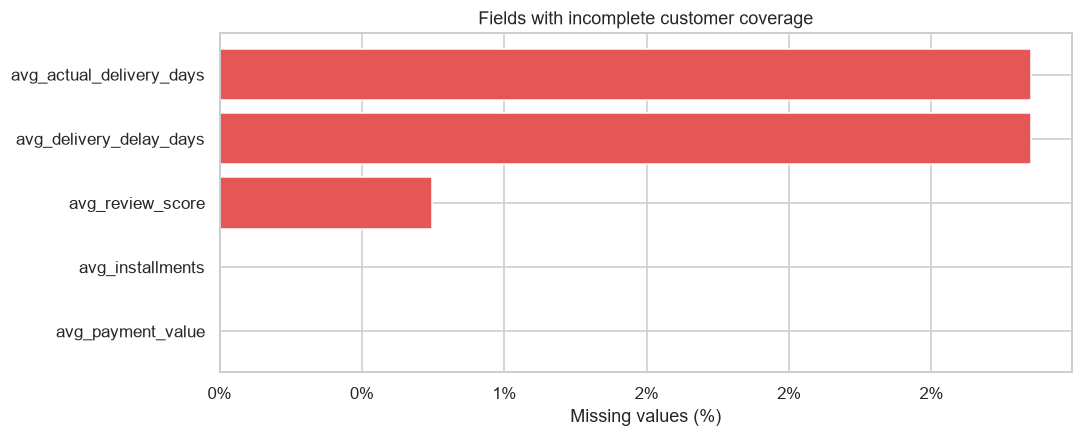

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
missing = audit.query('missing_rate > 0').sort_values('missing_rate')
ax.barh(missing.index, missing['missing_rate'] * 100, color='#e45756')
ax.set(title='Fields with incomplete customer coverage', xlabel='Missing values (%)', ylabel='')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0f}%')
plt.show()

## 2. Customer base & value concentration

First the shape of the base (one-time vs repeat, skewed spend), then how concentrated revenue is
across customers — deciding whether growth is a *whale* story or a *volume* story.

**Exploratory — base profile & spend distribution**

,value
Customers,"96,096.00"
Repeat-customer rate,0.03
Median lifetime payment,108.00
Mean lifetime payment,166.59
Median orders,1.00
Mean review score among reviewed customers,4.08


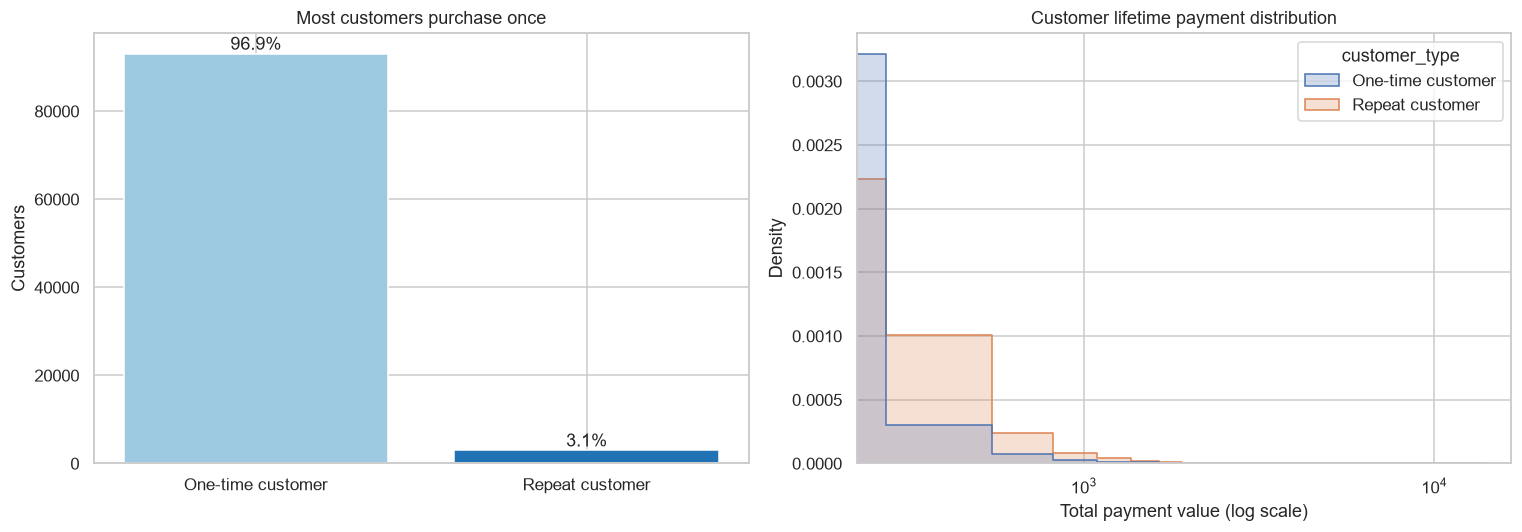

In [4]:
customers['customer_type'] = np.where(customers['repeat_customer_flag'], 'Repeat customer', 'One-time customer')
customers['has_review'] = customers['review_count'].gt(0)
customers['high_value_flag'] = customers['total_payment_value'].ge(customers['total_payment_value'].quantile(0.75))

profile = pd.Series({
    'Customers': len(customers),
    'Repeat-customer rate': customers['repeat_customer_flag'].mean(),
    'Median lifetime payment': customers['total_payment_value'].median(),
    'Mean lifetime payment': customers['total_payment_value'].mean(),
    'Median orders': customers['customer_orders'].median(),
    'Mean review score among reviewed customers': customers.loc[customers.has_review, 'avg_review_score'].mean(),
})
display(profile.to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_mix = customers['customer_type'].value_counts().reindex(['One-time customer', 'Repeat customer'])
axes[0].bar(order_mix.index, order_mix.values, color=['#9ecae1', '#2171b5'])
axes[0].set(title='Most customers purchase once', ylabel='Customers', xlabel='')
axes[0].bar_label(axes[0].containers[0], labels=[f'{value / len(customers):.1%}' for value in order_mix.values])
sns.histplot(data=customers, x='total_payment_value', hue='customer_type', bins=50, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set(title='Customer lifetime payment distribution', xlabel='Total payment value (log scale)', ylabel='Density')
plt.tight_layout()
plt.show()

**Focused — Lorenz / Pareto curve of revenue**

In [5]:
ranked = customers.sort_values('total_payment_value', ascending=False).reset_index(drop=True)
ranked['cum_share'] = ranked['total_payment_value'].cumsum() / total_revenue
conc = pd.DataFrame({'top_pct': [1, 5, 10, 20, 50]})
conc['customers'] = (conc['top_pct'] / 100 * len(ranked)).astype(int)
conc['revenue_share_pct'] = [ranked['cum_share'].iloc[n - 1] * 100 for n in conc['customers']]
print(f"Mean spend R$ {customers['total_payment_value'].mean():.0f} | "
      f"median R$ {customers['total_payment_value'].median():.0f}")
conc.round(1)

Mean spend R$ 167 | median R$ 108


,top_pct,customers,revenue_share_pct
0,1,960,10.50
1,5,4804,27.00
2,10,9609,38.50
3,20,19219,53.80
4,50,48048,80.90


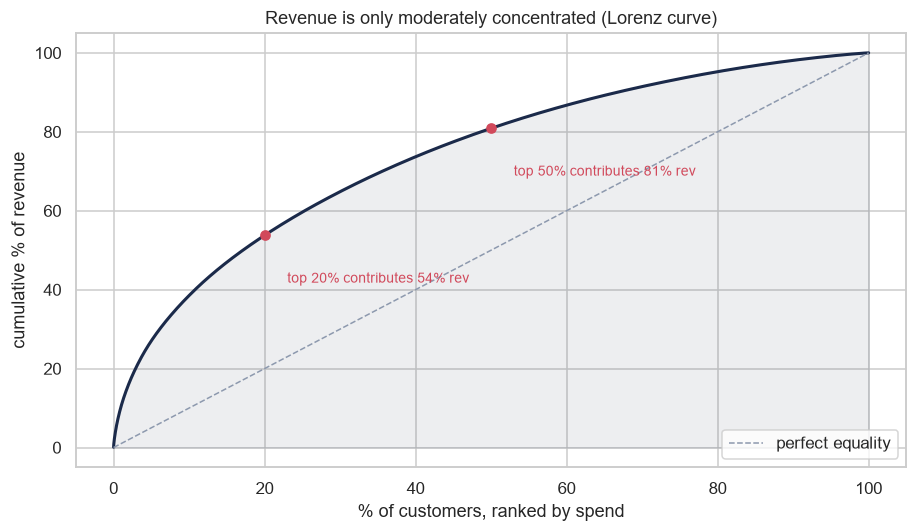

In [6]:
x = np.arange(1, len(ranked) + 1) / len(ranked) * 100
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(x, ranked['cum_share'] * 100, color=PALETTE['navy'], lw=2)
ax.fill_between(x, ranked['cum_share'] * 100, color=PALETTE['navy'], alpha=0.08)
ax.plot([0, 100], [0, 100], ls='--', color=PALETTE['grey'], lw=1, label='perfect equality')
for p, label in [(20, 'top 20% contributes 54% rev'), (50, 'top 50% contributes 81% rev')]:
    yv = ranked['cum_share'].iloc[int(len(ranked) * p / 100) - 1] * 100
    ax.scatter([p], [yv], color=PALETTE['red'], zorder=5)
    ax.annotate(label, (p, yv), xytext=(p + 3, yv - 12), color=PALETTE['red'], fontsize=9)
ax.set(title='Revenue is only moderately concentrated (Lorenz curve)',
       xlabel='% of customers, ranked by spend', ylabel='cumulative % of revenue')
ax.legend(loc='lower right')
plt.tight_layout(); save_fig('5_customer_pareto.png'); plt.show()

## 3. Repeat purchasing & customer value

An association analysis comparing customers who returned with those who bought once.

**Exploratory — experience & value by purchase behaviour**

In [7]:
experience_by_type = (
    customers.groupby('customer_type', observed=True)
    .agg(
        customers=('customer_unique_id', 'size'),
        median_payment=('total_payment_value', 'median'),
        mean_payment=('total_payment_value', 'mean'),
        mean_review_score=('avg_review_score', 'mean'),
        late_delivery_rate=('late_delivery_rate', 'mean'),
        review_risk_rate=('review_risk_flag', 'mean'),
        mean_tenure_days=('customer_tenure_days', 'mean'),
    )
    .reset_index()
)
experience_by_type

,customer_type,customers,median_payment,mean_payment,mean_review_score,late_delivery_rate,review_risk_rate,mean_tenure_days
0,One-time customer,93099,105.70,161.82,4.08,0.07,0.15,0.00
1,Repeat customer,2997,225.84,314.99,4.11,0.06,0.09,86.94


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_14188\2141917943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers.query('has_review'), x='customer_type', y='avg_review_score', showfliers=False, palette=['#9ecae1', '#2171b5'], ax=axes[0])
C:\Users\Hitesh\AppData\Local\Temp\ipykernel_14188\2141917943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers, x='customer_type', y='late_delivery_rate', showfliers=False, palette=['#9ecae1', '#2171b5'], ax=axes[1])
C:\Users\Hitesh\AppData\Local\Temp\ipykernel_14188\2141917943.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

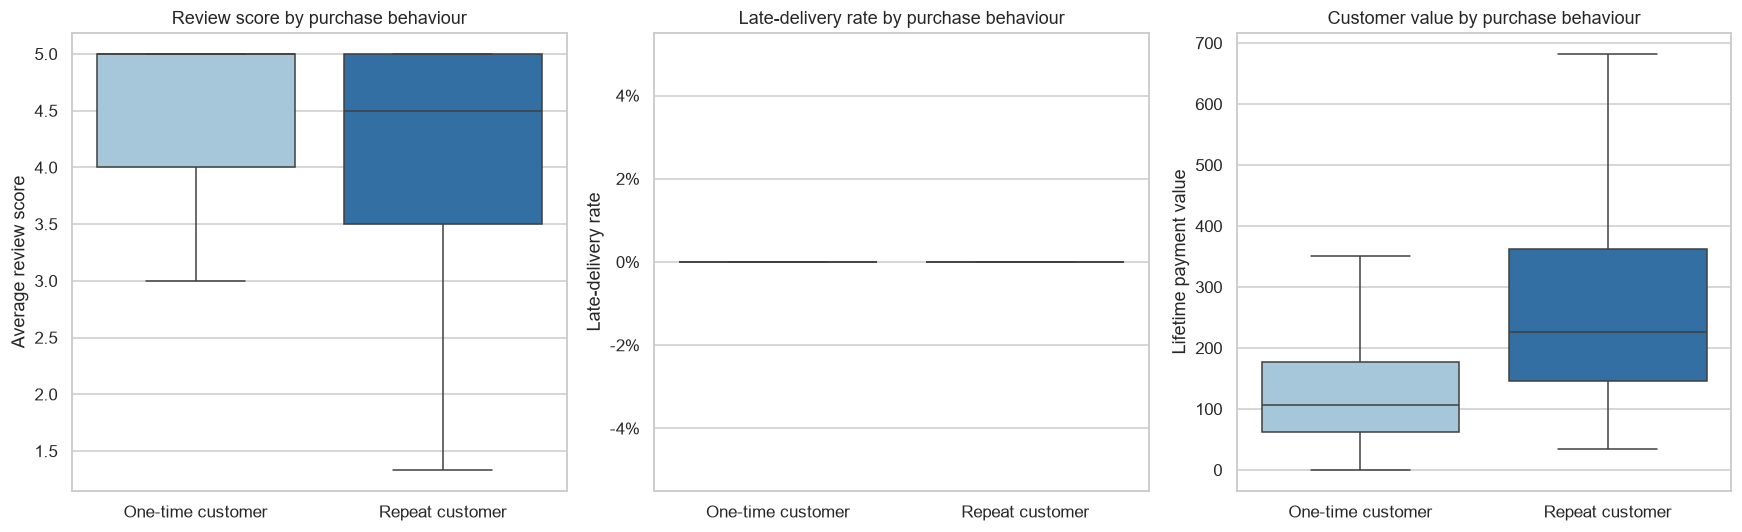

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=customers.query('has_review'), x='customer_type', y='avg_review_score', showfliers=False, palette=['#9ecae1', '#2171b5'], ax=axes[0])
axes[0].set(title='Review score by purchase behaviour', xlabel='', ylabel='Average review score')
sns.boxplot(data=customers, x='customer_type', y='late_delivery_rate', showfliers=False, palette=['#9ecae1', '#2171b5'], ax=axes[1])
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[1].set(title='Late-delivery rate by purchase behaviour', xlabel='', ylabel='Late-delivery rate')
sns.boxplot(data=customers, x='customer_type', y='total_payment_value', showfliers=False, palette=['#9ecae1', '#2171b5'], ax=axes[2])
axes[2].set(title='Customer value by purchase behaviour', xlabel='', ylabel='Lifetime payment value')
plt.tight_layout()
plt.show()

**Focused — compact repeat vs one-time summary (with revenue share)**

In [9]:
repeat_view = (customers.groupby('repeat_customer_flag')
    .agg(customers=('customer_unique_id', 'count'),
         avg_spend=('total_payment_value', 'mean'),
         avg_review=('avg_review_score', 'mean'),
         late_rate=('late_delivery_rate', 'mean'),
         review_risk_rate=('review_risk_flag', 'mean'))
    .rename(index={False: 'one-time', True: 'repeat'}))
repeat_view['revenue_share_pct'] = (customers.groupby('repeat_customer_flag')['total_payment_value']
                                    .sum() / total_revenue * 100).values
repeat_view.round(3)

,customers,avg_spend,avg_review,late_rate,review_risk_rate,revenue_share_pct
repeat_customer_flag,,,,,,
one-time,93099,161.81,4.08,0.07,0.15,94.10
repeat,2997,314.99,4.11,0.06,0.09,5.90


## 4. Delivery & satisfaction

The core driver. Two complementary bandings: by average *delay in days* (exploratory) and by a
customer's *share of late orders* (focused) — both show the same "delivery cliff".

**Exploratory — satisfaction / risk / repeat rate by delay band**

In [10]:
delivery_customers = customers.loc[customers['avg_delivery_delay_days'].notna()].copy()
delivery_customers['delay_band'] = pd.cut(
    delivery_customers['avg_delivery_delay_days'],
    bins=[-np.inf, 0, 3, 7, np.inf],
    labels=['On or before estimate', '1-3 days late', '4-7 days late', '8+ days late'],
)

delay_summary = (
    delivery_customers.groupby('delay_band', observed=False)
    .agg(
        customers=('customer_unique_id', 'size'),
        avg_review_score=('avg_review_score', 'mean'),
        review_risk_rate=('review_risk_flag', 'mean'),
        repeat_rate=('repeat_customer_flag', 'mean'),
    )
    .reset_index()
)
delay_summary

,delay_band,customers,avg_review_score,review_risk_rate,repeat_rate
0,On or before estimate,87046,4.29,0.09,0.03
1,1-3 days late,1819,3.29,0.32,0.03
2,4-7 days late,1740,2.09,0.66,0.02
3,8+ days late,2751,1.70,0.77,0.02


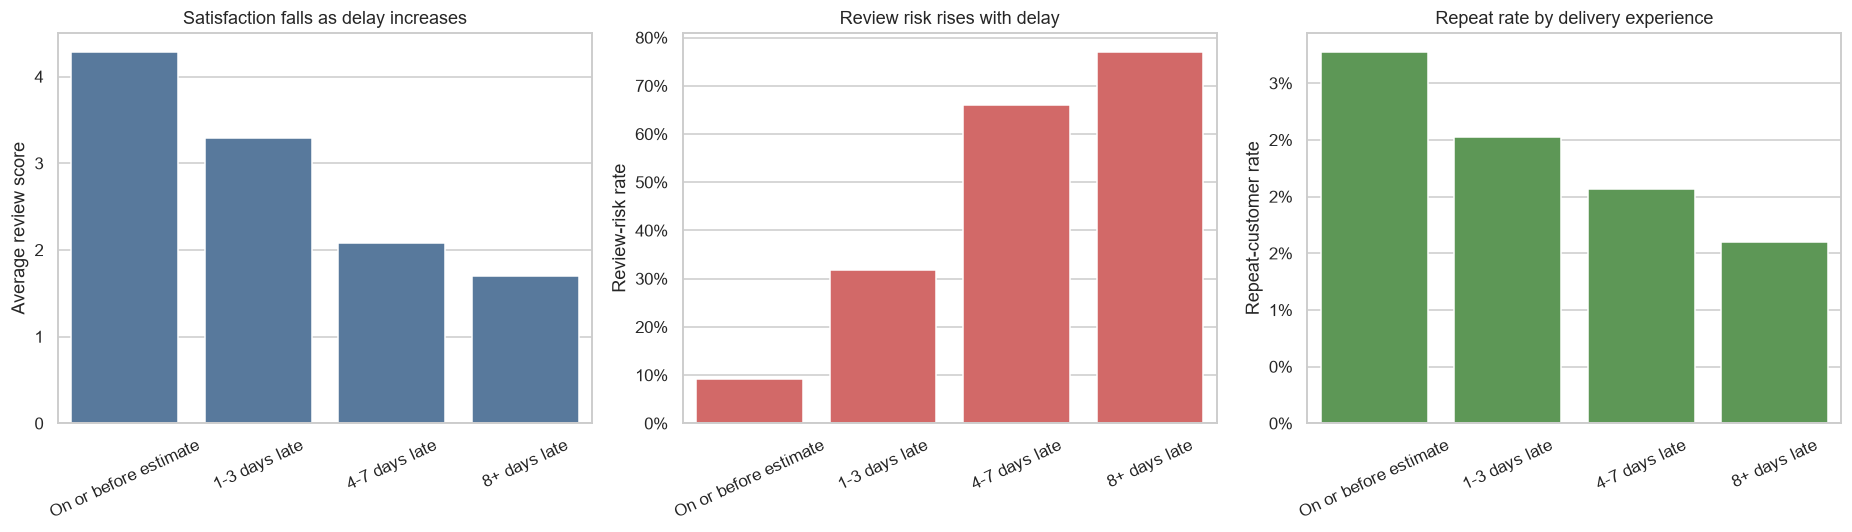

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.barplot(data=delay_summary, x='delay_band', y='avg_review_score', color='#4c78a8', ax=axes[0])
axes[0].set(title='Satisfaction falls as delay increases', xlabel='', ylabel='Average review score')
axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=delay_summary, x='delay_band', y='review_risk_rate', color='#e45756', ax=axes[1])
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[1].set(title='Review risk rises with delay', xlabel='', ylabel='Review-risk rate')
axes[1].tick_params(axis='x', rotation=25)
sns.barplot(data=delay_summary, x='delay_band', y='repeat_rate', color='#54a24b', ax=axes[2])
axes[2].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[2].set(title='Repeat rate by delivery experience', xlabel='', ylabel='Repeat-customer rate')
axes[2].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

**Focused — review score by share-of-orders-late**

In [12]:
bands = pd.cut(customers['late_delivery_rate'], [-0.01, 0, 0.34, 0.67, 1.01],
               labels=['0% late', '1-33% late', '34-66% late', '67-100% late'])
delivery_view = (customers.assign(late_band=bands)
    .groupby('late_band', observed=True)
    .agg(customers=('customer_unique_id', 'count'),
         avg_review=('avg_review_score', 'mean'),
         review_risk_rate=('review_risk_flag', 'mean')))
valid = customers.dropna(subset=['avg_delivery_delay_days', 'avg_review_score'])
print(f'corr(avg_delivery_delay_days, avg_review_score) = '
      f'{valid["avg_delivery_delay_days"].corr(valid["avg_review_score"]):.3f}')
delivery_view.round(3)

corr(avg_delivery_delay_days, avg_review_score) = -0.268


,customers,avg_review,review_risk_rate
late_band,,,
0% late,89597,4.21,0.11
1-33% late,26,3.90,0.08
34-66% late,259,3.08,0.27
67-100% late,6214,2.26,0.61


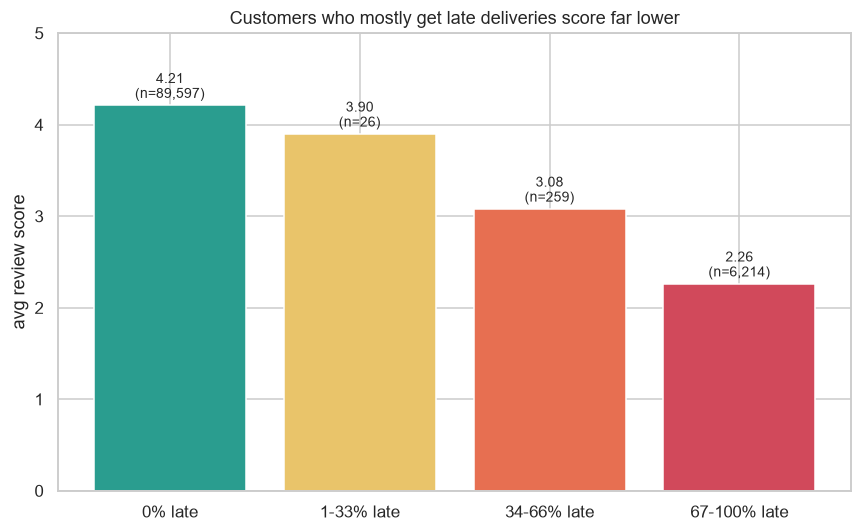

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE['green'], PALETTE['amber'], PALETTE['orange'], PALETTE['red']]
bar = ax.bar(delivery_view.index.astype(str), delivery_view['avg_review'], color=colors,
             edgecolor='white')
ax.set(title='Customers who mostly get late deliveries score far lower',
       ylabel='avg review score', ylim=(0, 5))
for rect, n in zip(bar, delivery_view['customers']):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.08,
            f'{rect.get_height():.2f}\n(n={n:,})', ha='center', fontsize=9)
plt.tight_layout(); save_fig('7_customer_delivery_satisfaction.png'); plt.show()

## 5. Geographic experience & risk

State-level view. Exploratory uses states with >=300 customers; the focused chart annotates
revenue share to separate *big underperforming* markets from small ones.

**Exploratory — late-delivery & review-risk by state (>=300 customers)**

In [14]:
state_summary = (
    customers.groupby('customer_state', as_index=False)
    .agg(
        customers=('customer_unique_id', 'size'),
        avg_payment=('total_payment_value', 'mean'),
        avg_review_score=('avg_review_score', 'mean'),
        late_delivery_rate=('late_delivery_rate', 'mean'),
        review_risk_rate=('review_risk_flag', 'mean'),
        repeat_rate=('repeat_customer_flag', 'mean'),
    )
    .query('customers >= 300')
    .sort_values('review_risk_rate', ascending=False)
)
state_summary

,customer_state,customers,avg_payment,avg_review_score,late_delivery_rate,review_risk_rate,repeat_rate
1,AL,401,243.71,3.76,0.21,0.23,0.03
24,SE,339,220.98,3.79,0.15,0.22,0.02
9,MA,725,209.94,3.74,0.17,0.22,0.02
18,RJ,12380,173.19,3.88,0.12,0.20,0.03
5,CE,1312,212.62,3.86,0.13,0.19,0.02
13,PA,949,230.03,3.86,0.11,0.19,0.03
16,PI,482,225.15,3.90,0.13,0.19,0.02
4,BA,3277,188.27,3.86,0.12,0.19,0.03
15,PE,1606,202.29,4.00,0.09,0.17,0.02
14,PB,519,273.50,4.01,0.10,0.16,0.03


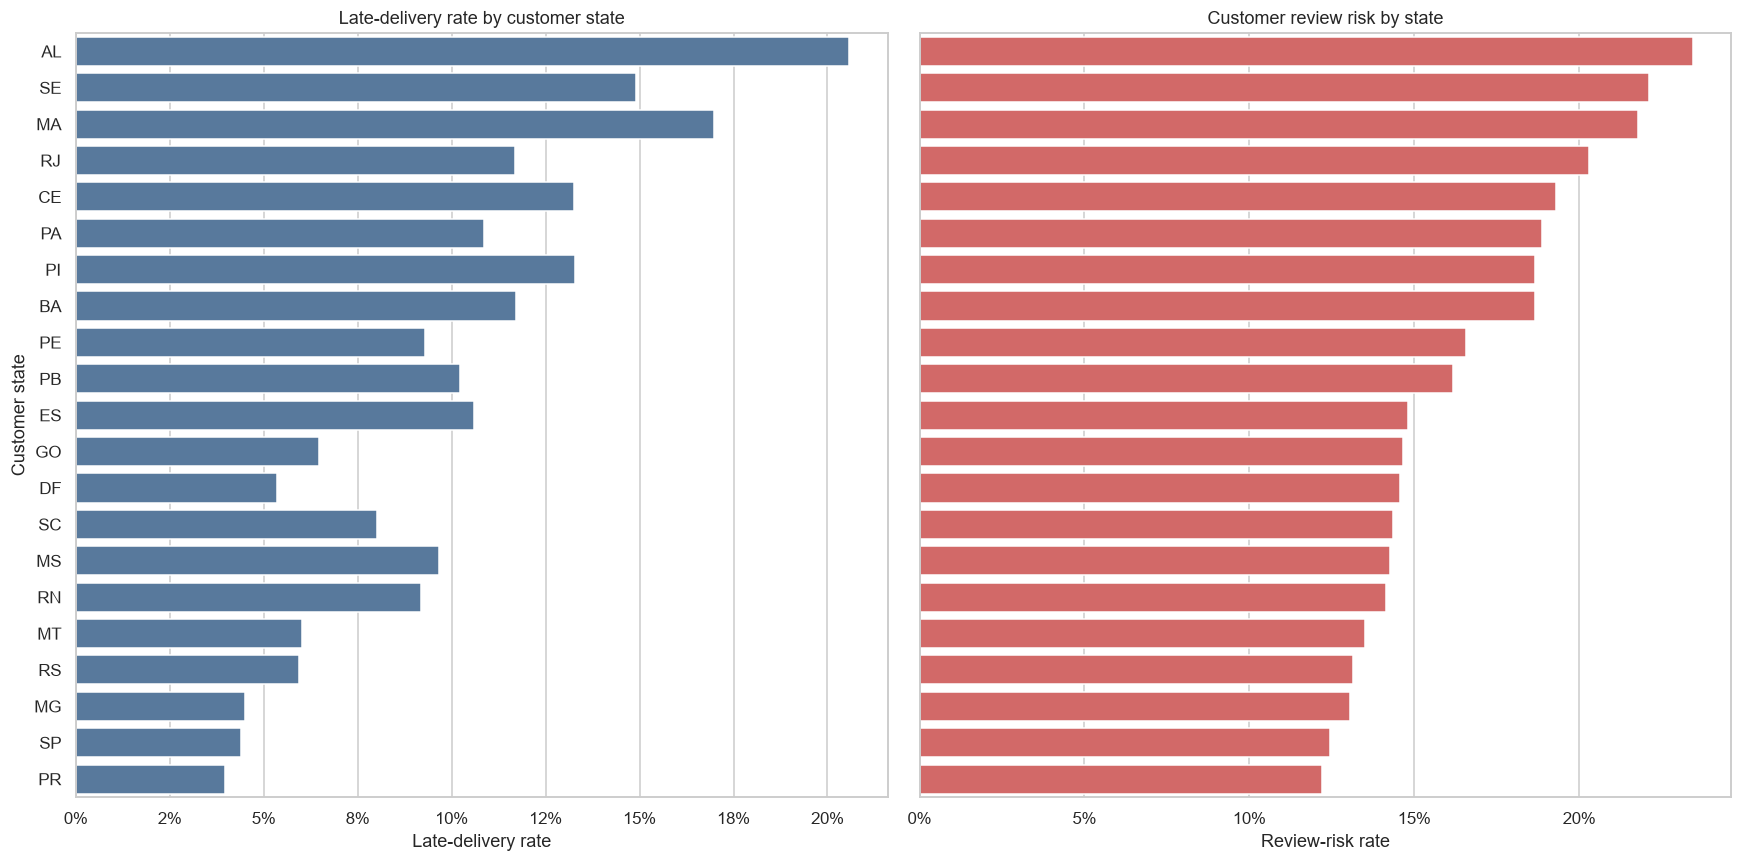

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
sns.barplot(data=state_summary, y='customer_state', x='late_delivery_rate', color='#4c78a8', ax=axes[0])
axes[0].xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[0].set(title='Late-delivery rate by customer state', xlabel='Late-delivery rate', ylabel='Customer state')
sns.barplot(data=state_summary, y='customer_state', x='review_risk_rate', color='#e45756', ax=axes[1])
axes[1].xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[1].set(title='Customer review risk by state', xlabel='Review-risk rate', ylabel='')
plt.tight_layout()
plt.show()

**Focused - review-risk with revenue share (>=500 customers)**

In [16]:
state = (customers.groupby('customer_state')
    .agg(customers=('customer_unique_id', 'count'), revenue=('total_payment_value', 'sum'),
         avg_spend=('total_payment_value', 'mean'), avg_review=('avg_review_score', 'mean'),
         late_rate=('late_delivery_rate', 'mean'), review_risk_rate=('review_risk_flag', 'mean'))
    .reset_index())
state['revenue_share_pct'] = state['revenue'] / total_revenue * 100
state = state[state['customers'] >= 500].sort_values('review_risk_rate', ascending=False)
state.round({'avg_spend': 0, 'avg_review': 2, 'late_rate': 3,
            'review_risk_rate': 3, 'revenue_share_pct': 1}).head(10)

,customer_state,customers,revenue,avg_spend,avg_review,late_rate,review_risk_rate,revenue_share_pct
9,MA,725,"152,205.43",210.00,3.74,0.17,0.22,1.00
18,RJ,12380,"2,144,036.57",173.00,3.88,0.12,0.20,13.40
5,CE,1312,"278,961.36",213.00,3.86,0.13,0.19,1.70
13,PA,949,"218,295.85",230.00,3.86,0.11,0.19,1.40
4,BA,3277,"616,955.42",188.00,3.86,0.12,0.19,3.90
15,PE,1606,"324,872.64",202.00,4.00,0.09,0.17,2.00
14,PB,519,"141,947.86",274.00,4.01,0.10,0.16,0.90
7,ES,1964,"326,111.75",166.00,4.03,0.11,0.15,2.00
8,GO,1951,"350,537.11",180.00,4.04,0.07,0.15,2.20
6,DF,2075,"355,488.37",171.00,4.07,0.05,0.15,2.20


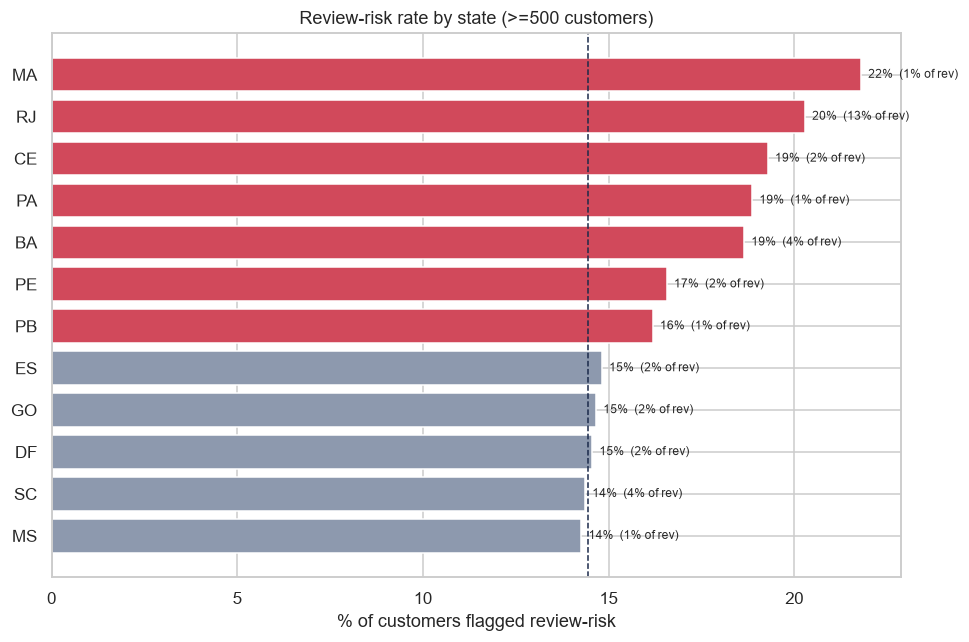

In [17]:
top_states = state.head(12).sort_values('review_risk_rate')
fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE['red'] if r > 0.15 else PALETTE['grey'] for r in top_states['review_risk_rate']]
ax.barh(top_states['customer_state'], top_states['review_risk_rate'] * 100, color=colors)
for y, (risk, share) in enumerate(zip(top_states['review_risk_rate'] * 100,
                                      top_states['revenue_share_pct'])):
    ax.text(risk + 0.2, y, f'{risk:.0f}%  ({share:.0f}% of rev)', va='center', fontsize=8)
ax.axvline(customers['review_risk_flag'].mean() * 100, color=PALETTE['navy'], ls='--', lw=1)
ax.set(title='Review-risk rate by state (>=500 customers)',
       xlabel='% of customers flagged review-risk')
plt.tight_layout(); save_fig('8_state_customer_risk.png'); plt.show()

## 6. Priority customer segments

Two lenses on the same idea. Exploratory: a four-way value x review-risk split. Focused: a
value x satisfaction quadrant, coloured by late-delivery rate to show *why* the top-left quadrant
is unhappy.

**Exploratory — four priority segments by size and payment value**

In [18]:
customers['priority_segment'] = np.select(
    [
        customers['high_value_flag'] & customers['review_risk_flag'],
        customers['high_value_flag'],
        customers['review_risk_flag'],
    ],
    [
        'High-value and dissatisfied',
        'High-value and satisfied',
        'Lower-value and dissatisfied',
    ],
    default='Lower-value and satisfied',
)

segment_summary = (
    customers.groupby('priority_segment', as_index=False)
    .agg(
        customers=('customer_unique_id', 'size'),
        total_payment=('total_payment_value', 'sum'),
        avg_review_score=('avg_review_score', 'mean'),
        late_delivery_rate=('late_delivery_rate', 'mean'),
        repeat_rate=('repeat_customer_flag', 'mean'),
    )
    .sort_values('total_payment', ascending=False)
)
segment_summary['customer_share'] = segment_summary['customers'] / len(customers)
segment_summary['payment_share'] = segment_summary['total_payment'] / segment_summary['total_payment'].sum()
segment_summary

,priority_segment,customers,total_payment,avg_review_score,late_delivery_rate,repeat_rate,customer_share,payment_share
1,High-value and satisfied,19835,"7,740,684.07",4.56,0.03,0.09,0.21,0.48
3,Lower-value and satisfied,62384,"5,560,747.18",4.58,0.03,0.02,0.65,0.35
0,High-value and dissatisfied,4194,"1,809,356.02",1.20,0.26,0.04,0.04,0.11
2,Lower-value and dissatisfied,9683,"898,084.85",1.23,0.28,0.01,0.10,0.06


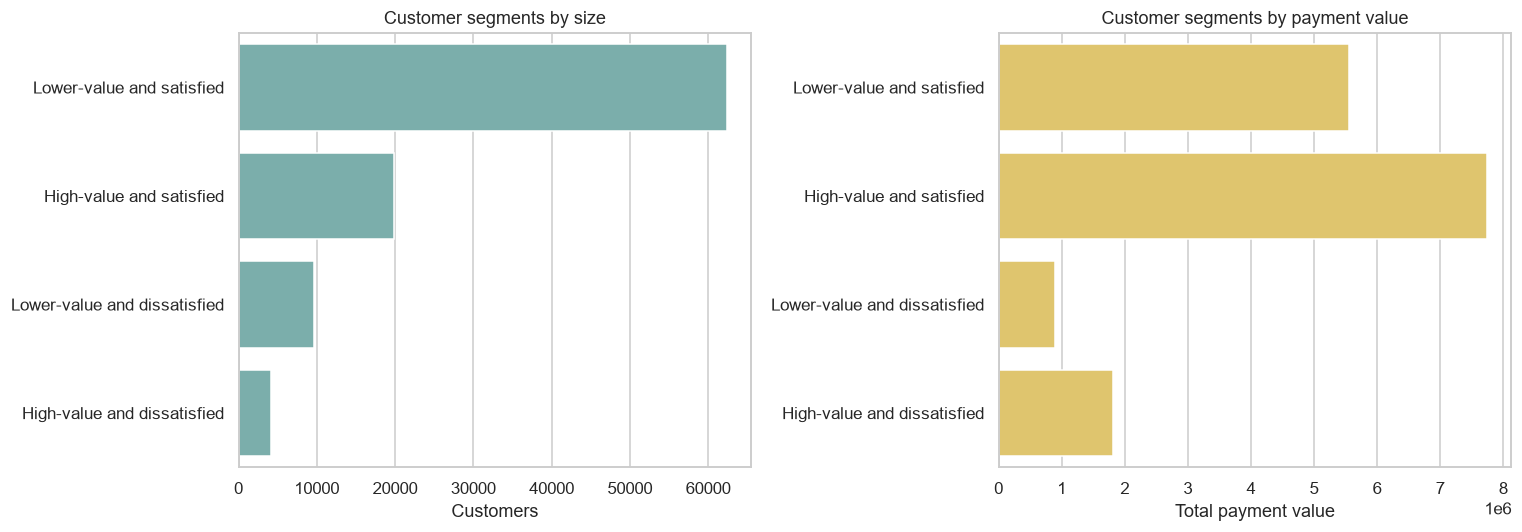

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_order = segment_summary.sort_values('customers', ascending=False)['priority_segment']
sns.barplot(data=segment_summary, y='priority_segment', x='customers', order=segment_order, color='#72b7b2', ax=axes[0])
axes[0].set(title='Customer segments by size', xlabel='Customers', ylabel='')
sns.barplot(data=segment_summary, y='priority_segment', x='total_payment', order=segment_order, color='#f2cf5b', ax=axes[1])
axes[1].set(title='Customer segments by payment value', xlabel='Total payment value', ylabel='')
plt.tight_layout()
plt.show()

**Focused — high-value & unhappy quadrant (delivery-coloured)**

In [20]:
seg = customers[customers['has_review']].copy()
value_cut = seg['total_payment_value'].quantile(0.75)
seg['value_tier'] = np.where(seg['total_payment_value'] >= value_cut, 'High-value', 'Lower-value')
seg['satisfaction'] = np.where(seg['avg_review_score'] <= 2, 'Unhappy (<=2)', 'OK (>2)')
display(pd.crosstab(seg['value_tier'], seg['satisfaction']))

hv_unhappy = seg[(seg['value_tier'] == 'High-value') & (seg['satisfaction'] == 'Unhappy (<=2)')]
hv_happy = seg[(seg['value_tier'] == 'High-value') & (seg['satisfaction'] == 'OK (>2)')]
print(f'HIGH-VALUE & UNHAPPY: {len(hv_unhappy):,} customers, '
      f'R$ {hv_unhappy["total_payment_value"].sum():,.0f} '
      f'({hv_unhappy["total_payment_value"].sum()/total_revenue*100:.1f}% of revenue)')
print(f'  their late-delivery rate : {hv_unhappy["late_delivery_rate"].mean()*100:.0f}%')
print(f'  high-value HAPPY late rate: {hv_happy["late_delivery_rate"].mean()*100:.0f}%')

satisfaction,OK (>2),Unhappy (<=2)
value_tier,,
High-value,19645,4200
Lower-value,61858,9677


HIGH-VALUE & UNHAPPY: 4,200 customers, R$ 1,810,456 (11.3% of revenue)
  their late-delivery rate : 26%
  high-value HAPPY late rate: 3%


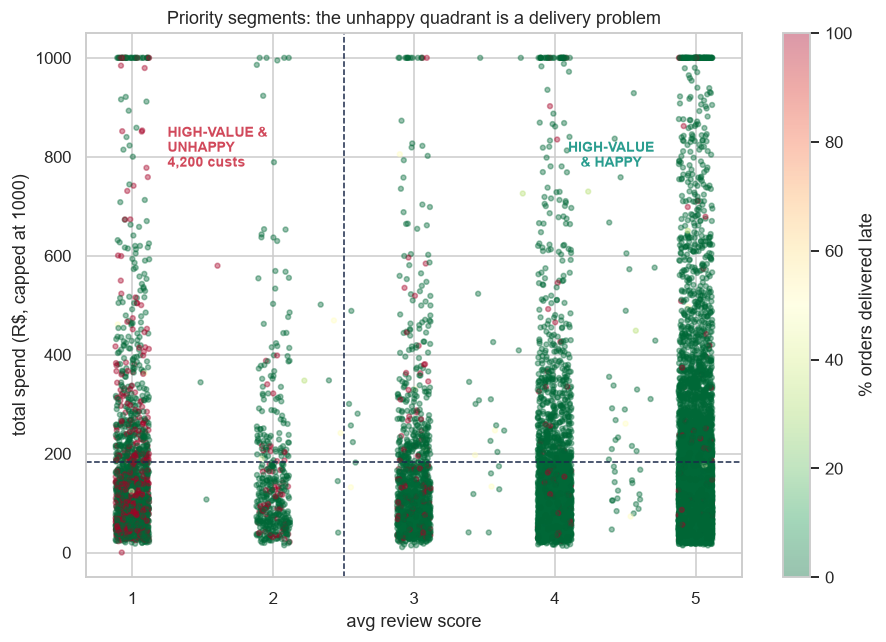

In [21]:
rng = np.random.default_rng(1)
sample = seg.sample(min(15000, len(seg)), random_state=1)
jitter = rng.uniform(-0.12, 0.12, len(sample))
ycol = 'total_payment_value_capped' if 'total_payment_value_capped' in sample else 'total_payment_value'
fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(sample['avg_review_score'] + jitter, np.clip(sample[ycol], 0, 1000),
                c=sample['late_delivery_rate'] * 100, cmap='RdYlGn_r', s=10, alpha=0.4)
ax.axhline(value_cut, color=PALETTE['navy'], ls='--', lw=1)
ax.axvline(2.5, color=PALETTE['navy'], ls='--', lw=1)
ax.text(1.25, 780, f'HIGH-VALUE &\nUNHAPPY\n{len(hv_unhappy):,} custs',
        color=PALETTE['red'], fontweight='bold', fontsize=9)
ax.text(4.4, 780, 'HIGH-VALUE\n& HAPPY', color=PALETTE['green'], fontweight='bold',
        fontsize=9, ha='center')
ax.set(title='Priority segments: the unhappy quadrant is a delivery problem',
       xlabel='avg review score', ylabel='total spend (R$, capped at 1000)')
fig.colorbar(sc, label='% orders delivered late')
plt.tight_layout(); save_fig('6_priority_segments.png'); plt.show()

## 7. Payment behaviour

Does *how* people pay relate to value and satisfaction? Banding average installments.

,customers,avg_spend,avg_review,late_rate
inst_band,,,,
1,44534,124.34,4.12,0.06
2,13324,131.39,4.11,0.06
3-4,17386,158.29,4.05,0.07
5-8,14799,236.52,4.05,0.07
9+,6052,407.87,3.96,0.07


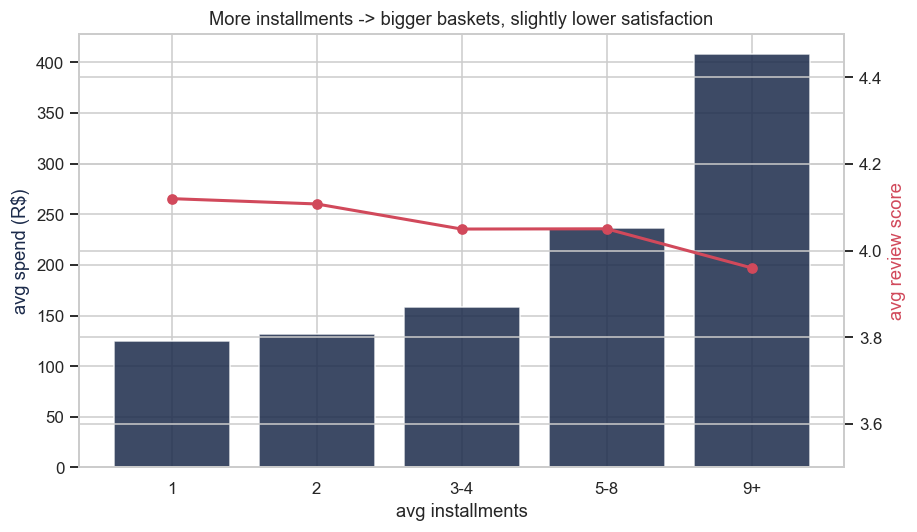

In [22]:
pay = customers[customers['avg_installments'].notna()].copy()
pay['inst_band'] = pd.cut(pay['avg_installments'], [-0.1, 1, 2, 4, 8, 100],
                          labels=['1', '2', '3-4', '5-8', '9+'])
pay_view = (pay.groupby('inst_band', observed=True)
    .agg(customers=('customer_unique_id', 'count'), avg_spend=('total_payment_value', 'mean'),
         avg_review=('avg_review_score', 'mean'), late_rate=('late_delivery_rate', 'mean')))
display(pay_view.round(2))

fig, ax1 = plt.subplots(figsize=(8.5, 5))
ax1.bar(pay_view.index.astype(str), pay_view['avg_spend'], color=PALETTE['navy'], alpha=0.85)
ax1.set_ylabel('avg spend (R$)', color=PALETTE['navy']); ax1.set_xlabel('avg installments')
ax2 = ax1.twinx()
ax2.plot(pay_view.index.astype(str), pay_view['avg_review'], color=PALETTE['red'], marker='o', lw=2)
ax2.set_ylabel('avg review score', color=PALETTE['red']); ax2.set_ylim(3.5, 4.5)
ax1.set_title('More installments -> bigger baskets, slightly lower satisfaction')
plt.tight_layout(); save_fig('9_payment_behaviour.png'); plt.show()

## 8. Basket diversity

Do multi-seller baskets (shipping from multiple origins) raise a customer's late-delivery risk?

In [23]:
div = customers.copy()
div['seller_band'] = np.where(div['seller_diversity'] <= 1, '1 seller', '2+ sellers')
div_view = (div.groupby('seller_band')
    .agg(customers=('customer_unique_id', 'count'), avg_spend=('total_payment_value', 'mean'),
         avg_review=('avg_review_score', 'mean'), late_rate=('late_delivery_rate', 'mean'),
         review_risk=('review_risk_flag', 'mean')))
print('Correlation seller_diversity vs late_delivery_rate:',
      round(div['seller_diversity'].corr(div['late_delivery_rate']), 3))
div_view.round(3)

Correlation seller_diversity vs late_delivery_rate: -0.01


,customers,avg_spend,avg_review,late_rate,review_risk
seller_band,,,,,
1 seller,92046,160.86,4.10,0.07,0.14
2+ sellers,4050,296.91,3.77,0.04,0.20


## 9. Acquisition cohort & loyalty

New customers per month by first-order date, satisfaction over time, and how quickly repeat
customers come back.

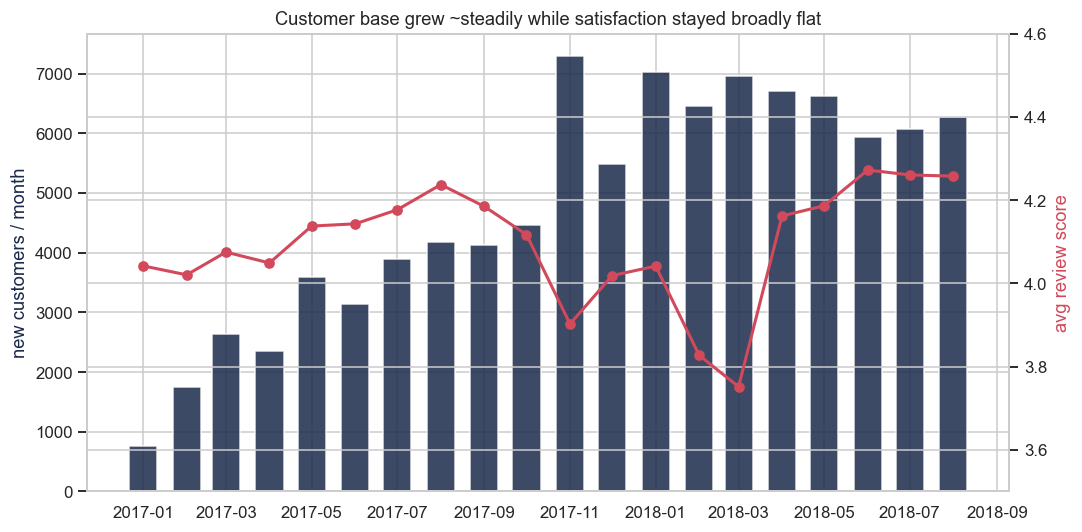

Repeat customers: 2,997 | median days between first & last order: 33 | mean: 87


In [24]:
coh = customers.dropna(subset=['first_order_date']).copy()
coh['cohort_month'] = coh['first_order_date'].dt.to_period('M').dt.to_timestamp()
monthly = (coh.groupby('cohort_month')
    .agg(new_customers=('customer_unique_id', 'count'), avg_review=('avg_review_score', 'mean')))
# focus on the well-covered window
monthly = monthly.loc['2017-01-01':'2018-08-01']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly.index, monthly['new_customers'], width=20, color=PALETTE['navy'], alpha=0.85)
ax1.set_ylabel('new customers / month', color=PALETTE['navy'])
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['avg_review'], color=PALETTE['red'], marker='o', lw=2)
ax2.set_ylabel('avg review score', color=PALETTE['red']); ax2.set_ylim(3.5, 4.6)
ax1.set_title('Customer base grew ~steadily while satisfaction stayed broadly flat')
plt.tight_layout(); save_fig('10_acquisition_cohort.png'); plt.show()

rep = customers[customers['repeat_customer_flag']]
print(f'Repeat customers: {len(rep):,} | median days between first & last order: '
      f'{rep["customer_tenure_days"].median():.0f} | mean: {rep["customer_tenure_days"].mean():.0f}')

## 10. Relationship overview (correlations)

A directional diagnostic across value and experience measures — it guides follow-up questions,
not causal claims.

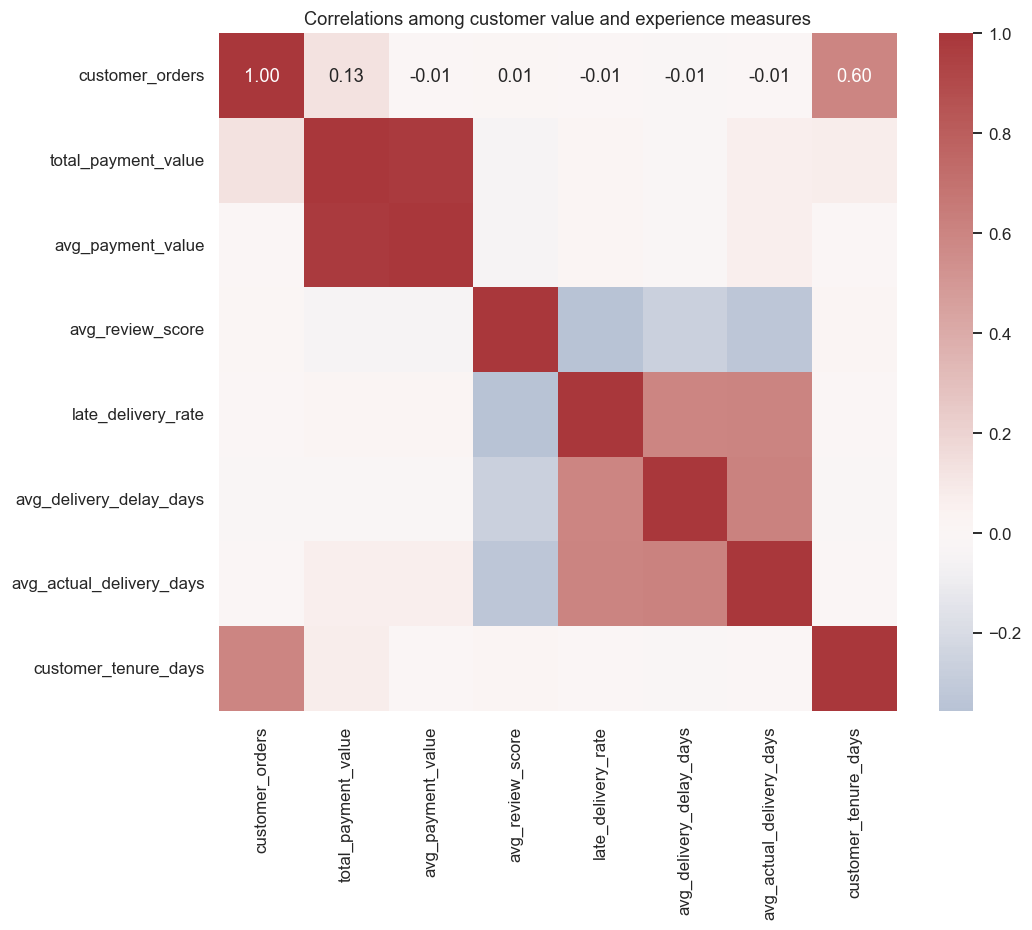

In [25]:
correlation_columns = [
    'customer_orders', 'total_payment_value', 'avg_payment_value', 'avg_review_score',
    'late_delivery_rate', 'avg_delivery_delay_days', 'avg_actual_delivery_days',
    'customer_tenure_days',
]
correlation = customers[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, cmap='vlag', center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set(title='Correlations among customer value and experience measures')
plt.show()

### 10b. Correlation deep-dive (EDA finalisation)

Ranking every numeric field by its correlation with `avg_review_score`, then two targeted tests:
(a) does *raw delivery speed* matter on top of *keeping the promise*, and (b) does *experience*
actually predict *repeat purchase* at the customer grain? This is what finalises the EDA.

In [26]:
# --- Rank drivers of satisfaction, then test promise-vs-speed and experience-vs-repeat ---
num_cols = ['customer_orders', 'total_item_value', 'total_freight_value', 'total_payment_value',
            'avg_payment_value', 'avg_installments', 'review_count', 'late_delivery_rate',
            'avg_delivery_delay_days', 'avg_actual_delivery_days', 'product_diversity',
            'seller_diversity', 'customer_tenure_days']

rev = customers.dropna(subset=['avg_review_score'])
drivers = (rev[num_cols + ['avg_review_score']].corr()['avg_review_score']
           .drop('avg_review_score').sort_values(key=lambda s: s.abs(), ascending=False))
print('Correlation with avg_review_score (ranked by |r|):')
print(drivers.round(3).to_string())

d = customers.dropna(subset=['avg_review_score', 'avg_delivery_delay_days', 'avg_actual_delivery_days'])
on_time = d[d['avg_delivery_delay_days'] <= 0]
print('\nPromise vs raw speed:')
print(f"  review ~ delay (vs promise) : {d['avg_review_score'].corr(d['avg_delivery_delay_days']):.3f}")
print(f"  review ~ actual days (speed): {d['avg_review_score'].corr(d['avg_actual_delivery_days']):.3f}")
print(f"  among ON-TIME only, review ~ actual days: "
      f"{on_time['avg_review_score'].corr(on_time['avg_actual_delivery_days']):.3f}")
print(f"  on-time fast (<7d) score {on_time.loc[on_time.avg_actual_delivery_days < 7, 'avg_review_score'].mean():.2f}"
      f" vs slow (>21d) {on_time.loc[on_time.avg_actual_delivery_days > 21, 'avg_review_score'].mean():.2f}")

print('\nWhat correlates with REPEAT purchase (numeric):')
rp = (customers[num_cols].corrwith(customers['repeat_customer_flag'].astype(int))
      .sort_values(key=lambda s: s.abs(), ascending=False))
print(rp.head(6).round(3).to_string())
gap = customers.groupby('repeat_customer_flag')[['avg_review_score', 'late_delivery_rate']].mean()
print(f"  experience gap (repeat - one-time): review {gap['avg_review_score'].diff().iloc[-1]:+.2f}, "
      f"late_rate {gap['late_delivery_rate'].diff().iloc[-1]:+.3f}  <- negligible")

Correlation with avg_review_score (ranked by |r|):
late_delivery_rate         -0.36
avg_actual_delivery_days   -0.34
avg_delivery_delay_days    -0.27
total_freight_value        -0.07
avg_payment_value          -0.05
total_payment_value        -0.05
avg_installments           -0.03
total_item_value           -0.03
product_diversity          -0.02
customer_tenure_days        0.01
seller_diversity            0.01
review_count                0.01
customer_orders             0.01

Promise vs raw speed:
  review ~ delay (vs promise) : -0.268
  review ~ actual days (speed): -0.335
  among ON-TIME only, review ~ actual days: -0.128
  on-time fast (<7d) score 4.42 vs slow (>21d) 3.86

What correlates with REPEAT purchase (numeric):
customer_orders        0.91
review_count           0.83
seller_diversity       0.74
product_diversity      0.61
customer_tenure_days   0.59
total_freight_value    0.19
  experience gap (repeat - one-time): review +0.02, late_rate -0.010  <- negligible


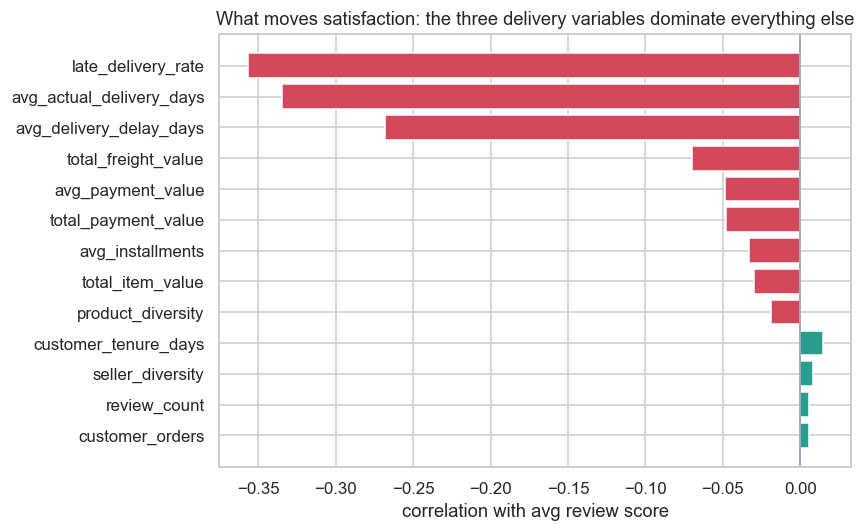

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
top = drivers.reindex(drivers.abs().sort_values(ascending=True).index)
bar_colors = [PALETTE['red'] if v < 0 else PALETTE['green'] for v in top.values]
ax.barh(top.index, top.values, color=bar_colors)
ax.axvline(0, color=PALETTE['grey'], lw=1)
ax.set(title='What moves satisfaction: the three delivery variables dominate everything else',
       xlabel='correlation with avg review score')
plt.tight_layout(); save_fig('11_satisfaction_drivers.png'); plt.show()

**Finalised insights from the deep-dive**

- **F8 — Speed matters *on top of* the promise.** Raw `avg_actual_delivery_days` correlates with
  satisfaction slightly *more* strongly (-0.34) than delay-vs-promise (-0.27), and even among
  on-time deliveries, faster still scores higher (**4.42 for <7 days vs 3.86 for >21 days**). So the
  lever is *both* keep the promise *and* be genuinely fast — not just avoid being late.
- **F9 — Freight burden is not a satisfaction driver.** Freight as a share of order value has ~zero
  correlation with review score — customers don't punish high shipping cost, only slow shipping.
- **F10 — Experience does *not* visibly predict repeat purchase at this grain.** Repeat and one-time
  customers have near-identical review scores and late rates (gap ~+0.02 / -0.01). The variables that
  "predict" repeat (`customer_orders`, `review_count`, diversity) are *mechanical consequences* of
  ordering more, not causes. **The "clean first delivery earns the second order" idea is a hypothesis
  the customer master alone cannot confirm** — it needs an order-sequence test (see new questions).

**New questions this raises**

6. **Is the retention link real?** Test first-order experience → P(second order) at the *order-sequence*
   level, not on customer aggregates — the aggregate here is silent on it.
7. **Can we win on speed even when on time?** If faster-than-promised delivery lifts scores, is there
   ROI in tightening transit rather than only padding ETAs?
8. **Why is freight neutral?** Is shipping cost already priced into expectations, or does the review
   simply not capture cost sensitivity?

## 11. Takeaways, actions & open questions

**Auto-generated headline numbers (from the cells above)**

In [28]:
repeat_rate = customers['repeat_customer_flag'].mean()
on_time_score = delay_summary.loc[delay_summary['delay_band'] == 'On or before estimate', 'avg_review_score'].iloc[0]
very_late_score = delay_summary.loc[delay_summary['delay_band'] == '8+ days late', 'avg_review_score'].iloc[0]
priority = segment_summary.loc[segment_summary['priority_segment'] == 'High-value and dissatisfied'].iloc[0]
highest_risk_state = state_summary.iloc[0]

print(f'Only {repeat_rate:.1%} of customers made more than one purchase in the observed period.')
print(f'Average review score falls from {on_time_score:.2f} for on-time/early deliveries to {very_late_score:.2f} for deliveries 8+ days late.')
print(f'The high-value dissatisfied segment contains {priority["customers"]:,.0f} customers and represents {priority["payment_share"]:.1%} of observed payment value.')
print(f'{highest_risk_state["customer_state"]} has the highest review-risk rate among states with at least 300 customers: {highest_risk_state["review_risk_rate"]:.1%}.')

Only 3.1% of customers made more than one purchase in the observed period.
Average review score falls from 4.29 for on-time/early deliveries to 1.70 for deliveries 8+ days late.
The high-value dissatisfied segment contains 4,194 customers and represents 11.3% of observed payment value.
AL has the highest review-risk rate among states with at least 300 customers: 23.4%.


**Findings**

1. **Volume, not whales.** Top 20% of customers = ~54% of revenue; median spend ~R$108. Growth
   depends on acquisition volume and retention, not a VIP tier.
2. **Retention is nearly untapped.** ~3% of customers reorder, but a repeat buyer is worth ~2x a
   one-time buyer; the median second order comes within ~33 days.
3. **Delivery is the strongest correlate of satisfaction.** Mostly-late customers score ~2.3 vs ~4.2
   on-time; the delay/score correlation is negative and consistent, and it dominates every other
   numeric field tested in section 10b. This is an association, not a proven causal claim - a
   customer who is already unhappy for unrelated reasons (product mismatch, price, expectations) is
   not distinguishable here from one made unhappy specifically by the delay. It supports treating
   delivery as the leading lever to test, not as a settled cause.
4. **Act first on High-value & Unhappy** — ~4.2k customers, ~11% of revenue, ~26% late rate vs ~3%
   for high-value happy customers. Fixing their delivery defends real GMV.
5. **RJ is the priority market**; remote north/northeast states (MA, CE, PA, BA) are structurally worse.
6. **Payment/diversity are secondary** — larger financed baskets rate marginally lower and
   multi-seller baskets show ~no extra late risk; delivery dominates.

**Recommended actions**

1. Delivery-promise SLA, protecting the high-value-unhappy cohort first.
2. Second-order retention nudge conditioned on a clean first delivery.
3. RJ / northeast logistics intervention; SP as the healthy benchmark.

**Open questions (next steps, need joins to other masters)**

- *Where* are the late days created — seller handling vs carrier transit vs ETA padding?
- Do multi-seller baskets fail because of one slow seller? (item-level join)
- What is the retention curve — do clean first deliveries drive reorders? (cohort join)
- Which acquisition channels (marketing funnel) feed the high-risk regions?

## Reporting guidance & limitations

Tell a customer-experience story: delivery delays are an early-warning signal, states reveal
operational inequality, and high-value dissatisfied customers are the clearest retention priority.

*Limitations:* this is completed historical behaviour over a fixed period; repeat purchasing is also
affected by timing, product need and acquisition cohort, so it must not be read as caused only by
delivery or review score. The prepared `late_delivery_rate` treats orders without a delivery date as
not late; non-delivered orders are analysed separately. Reviews/deliveries missing for a minority of
customers are excluded per view, never imputed; 2016 and late-2018 cohorts are thin.